In [1]:
import cv2
import numpy
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [2]:
%%cmd
git clone https://github.com/xavysp/DexiNed.git

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>git clone https://github.com/xavysp/DexiNed.git


Cloning into 'DexiNed'...



C:\Qualcomm\AIStack\models\Edge_Detection>

In [3]:
%%cmd
cd DexiNed
git apply "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\onnx_export_512_288.patch"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>git apply "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\onnx_export_512_288.patch"


C://Qualcomm//AIStack//models//Edge_Detection//assets//onnx_export_512_288.patch:82: trailing whitespace.
        
C://Qualcomm//AIStack//models//Edge_Detection//assets//onnx_export_512_288.patch:43: new blank line at EOF.
+
C://Qualcomm//AIStack//models//Edge_Detection//assets//onnx_export_512_288.patch:90: new blank line at EOF.
+
C://Qualcomm//AIStack//models//Edge_Detection//assets//onnx_export_512_288.patch:115: new blank line at EOF.
+



C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

#### Setup artifacts
#####  Download 10_model.pth from link provided in DexiNed\README.md to path DexiNed\checkpoints\BIPED\10

In [14]:
%%cmd
cd DexiNed
python main.py

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>python main.py


C:\Ashwath\envs\python3.8_acer_notebooks\lib\site-packages\torch\utils\data\dataloader.py:558: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Number of GPU's available: 0
Pytorch version: 2.2.1+cpu
mean_bgr: [103.939, 116.779, 123.68]
output_dir: result\BIPED2BIPED
Restoring weights from: checkpoints\BIPED\10/10_model.pth
input tensor shape: torch.Size([1, 3, 288, 512])
preds =  torch.Size([1, 1, 288, 512])
input tensor shape: torch.Size([1, 3, 288, 512])
preds =  torch.Size([1, 1, 288, 512])
input tensor shape: torch.Size([1, 3, 288, 512])
preds =  torch.Size([1, 1, 288, 512])
input tensor shape: torch.Size([1, 3, 288, 512])
preds =  torch.Size([1, 1, 288, 512])
input tensor shape: torch.Size([1, 3, 288, 512])
preds =  torch.Size([1, 1, 288, 512])
******** Testing finished in BIPED dataset. *****
FPS: 0.145224.4
-------------------------------------------------------
DexiNed # of Parameters:
35215245
-------------------------------------------------------

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [15]:
image_name = "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\input_images\\edge.jpg"
input_image = cv2.imread(image_name)
print(input_image.shape)
input_image = cv2.resize(input_image,(512,288))
print(input_image.shape)
input_image.astype(np.float32).tofile("DexiNed\input_512_288.raw")


(288, 512, 3)
(288, 512, 3)


In [16]:
with open("DexiNed/input_list_512_288.txt","w") as file:
    for raw in os.listdir("DexiNed/"):
        if "input_512_288.raw" in raw:
            file.write(raw)

In [17]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

In [18]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, "DexiNed")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "DexiNed")

In [19]:
'''
[NOT TESTED]
If you want to convert the model to int16 instead of int8, please use the following command in the cell below: 
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" ^
    -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" ^
    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp" ^
    --act_bw 16 --weight_bw 16 --bias_bw 8
'''

'\n[NOT TESTED]\nIf you want to convert the model to int16 instead of int8, please use the following command in the cell below: \npython "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\x08in\x07rm64x-windows-msvc\\qnn-onnx-converter" ^\n    -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" ^\n    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp" ^\n    --act_bw 16 --weight_bw 16 --bias_bw 8\n'

In [20]:

%%cmd
cd DexiNed
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\dexined_512_288.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\dexined_512_288.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp"


2024-06-15 01:31:40,489 - 235 - INFO - Skipping quantization, no input_list provided
2024-06-15 01:31:40,489 - 235 - INFO - Saving QNN Model...
2024-06-15 01:31:40,721 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp 
2024-06-15 01:31:40,721 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Edge_Detection\assets\float32\dexined_512_288.bin 
2024-06-15 01:31:40,747 - 235 - INFO - Conversion complete!



C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [21]:
%%cmd
cd DexiNed
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\dexined_512_288.onnx" --input_list input_list_512_288.txt -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\dexined_512_288.onnx" --input_list input_list_512_288.txt -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp"


2024-06-15 01:32:04,939 - 235 - INFO - Saving QNN Model...
2024-06-15 01:32:05,034 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp 
2024-06-15 01:32:05,034 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Edge_Detection\assets\int8\dexined_512_288.bin 
2024-06-15 01:32:05,034 - 235 - INFO - Conversion complete!


     4.6ms [  INFO ] Inferences will run in sync mode
     5.0ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDBDBD7810], Log Level: [3]
     5.0ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
     5.1ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
     5.3ms [  INFO ] Entering QuantizeRuntimeApp flow
   365.5ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   403.3ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
  2707.8ms [  INFO ] cleaning up resources for input tensors
  2707.9ms [  INFO ] cleaning up resources for output tensors
  2797.1ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [22]:
%%cmd
cd DexiNed
mkdir "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs"
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.bin" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\float32\\" -t windows-aarch64

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>mkdir "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs"


A subdirectory or file C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs already exists.



C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.bin" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\float32\\" -t windows-aarch64


2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.cpp
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\float32\\dexined_512_288.bin
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\float32\
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 01:32:05,258 -    INFO - qnn-model-lib-generator: Output library name  : dexined_512_288.dll
2024-06-15 01:32:05,524 -


C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [23]:
%%cmd
cd DexiNed
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.bin" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\int8\\" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.bin" -o "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\int8\\" -t windows-aarch64 


2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.cpp
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\int8\\dexined_512_288.bin
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\int8\
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 01:33:19,316 -    INFO - qnn-model-lib-generator: Output library name  : dexined_512_288.dll
2024-06-15 01:33:19,545 -    INFO 


C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [24]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open(".\\DexiNed\\htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [26]:
%%cmd
cd DexiNed
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\int8\ARM64\dexined_512_288.dll"  --backend "QnnHtp.dll" --binary_file dexined_512_288.serialized --config_file "htp_backend_extensions.json"
move  output\dexined_512_288.serialized.bin "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\edge_quantized.serialized.v73.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\int8\ARM64\dexined_512_288.dll"  --backend "QnnHtp.dll" --binary_file dexined_512_288.serialized --config_file "htp_backend_extensions.json"
qnn-context-binary-generator pid:18208
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (166 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (286228 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (1236469 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (94666 us)
Starting stage: Parallelization Optimization
Complet

In [27]:
%%cmd 
cd DexiNed
rmdir /s  output_cpu
Y
rmdir /s  output_dsp 
Y

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>rmdir /s  output_cpu
output_cpu, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>rmdir /s  output_dsp 
output_dsp, Are you sure (Y/N)? Y


The system cannot find the file specified.
The system cannot find the file specified.



C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [28]:
%%cmd
cd DexiNed
qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\float32\ARM64\dexined_512_288.dll" --input_list input_list_512_288.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\model_libs\\float32\ARM64\dexined_512_288.dll" --input_list input_list_512_288.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:10684

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [29]:
%%cmd
cd DexiNed
qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\edge_quantized.serialized.v73.bin" --input_list input_list_512_288.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Edge_Detection\\assets\\edge_quantized.serialized.v73.bin" --input_list input_list_512_288.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:14136
     0.0ms [WARNING] QnnDsp <W> Function not called, PrepareLib isn't loaded!


C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>

In [30]:
def image_normalization(img, img_min=0, img_max=255,
                        epsilon=1e-12):
    """This is a typical image normalization function
    where the minimum and maximum of the image is needed
    source: https://en.wikipedia.org/wiki/Normalization_(image_processing)

    :param img: an image could be gray scale or color
    :param img_min:  for default is 0
    :param img_max: for default is 255

    :return: a normalized image, if max is 255 the dtype is uint8
    """

    img = np.float32(img)
    # whenever an inconsistent image
    img = (img - np.min(img)) * (img_max - img_min) / \
        ((np.max(img) - np.min(img)) + epsilon) + img_min
    return img


In [31]:
def postprocess(path):
    
    plt.figure(dpi=100)
    
    #subplot(r,c) provide the no. of rows and columns
    f, axarr = plt.subplots(1,3,figsize=(20, 20)) 
    axarr[0].imshow(imread(image_name))
    
    fuse_name = 'fused'
    av_name = 'avg'
    tensor2=None
    tmp_img2 = None
    results = []
    for id,OUTPUT in enumerate(path):
        for id,result in enumerate(os.listdir(OUTPUT)):
            if "log" not in result:
                edge_maps = []
                for raw in ["onnx__Concat_458.raw","onnx__Concat_461.raw","onnx__Concat_467.raw","onnx__Concat_476.raw","onnx__Concat_488.raw","onnx__Concat_500.raw",
            "_502.raw"]:
                    x = np.fromfile(OUTPUT+result+"/"+raw,dtype="float32").reshape(1,1,288,512)
                    i = torch.from_numpy(x)
                    tmp = torch.sigmoid(i).cpu().detach().numpy()
                    edge_maps.append(tmp)
                tensor = np.array(edge_maps)
                img_shape = [torch.tensor([288]), torch.tensor([512])]
                image_shape = [x.cpu().detach().numpy() for x in img_shape]
                # (H, W) -> (W, H)
                image_shape = [[y, x] for x, y in zip(image_shape[0], image_shape[1])]
            
                idx = 0
                for i_shape, file_name in zip(image_shape, [f"{id}.png"]):
                    tmp = tensor[:, idx, ...]
                    tmp2 = tensor2[:, idx, ...] if tensor2 is not None else None
                    tmp = np.squeeze(tmp)
                    tmp2 = np.squeeze(tmp2) if tensor2 is not None else None
                    # Iterate our all 7 NN outputs for a particular image
                    preds = []
                    for i in range(tmp.shape[0]):
                        tmp_img = tmp[i]
                        tmp_img = np.uint8(image_normalization(tmp_img))
                        tmp_img = cv2.bitwise_not(tmp_img)
                        preds.append(tmp_img)
                
                        if i == 6:
                            fuse = tmp_img
                            fuse = fuse.astype(np.uint8)
                
                    # Get the mean prediction of all the 7 outputs
                    average = np.array(preds, dtype=np.float32)
                    average = np.uint8(np.mean(average, axis=0))
                    # output_file_name_f = os.path.join("./", file_name)
                    # output_file_name_a = os.path.join("./", "a_"+file_name)
            
                    # cv2.imwrite(output_file_name_f, fuse)
                    # cv2.imwrite(output_file_name_a, average)
                    # plt.imshow(average,cmap='gray')

                    results.append(average)
                    idx += 1
    axarr[1].imshow(results[0],cmap='gray')
    axarr[2].imshow(results[1],cmap='gray')

    axarr[0].title.set_text('Input image')
    axarr[1].title.set_text('CPU')
    axarr[2].title.set_text('HTP')
                
                    


<Figure size 640x480 with 0 Axes>

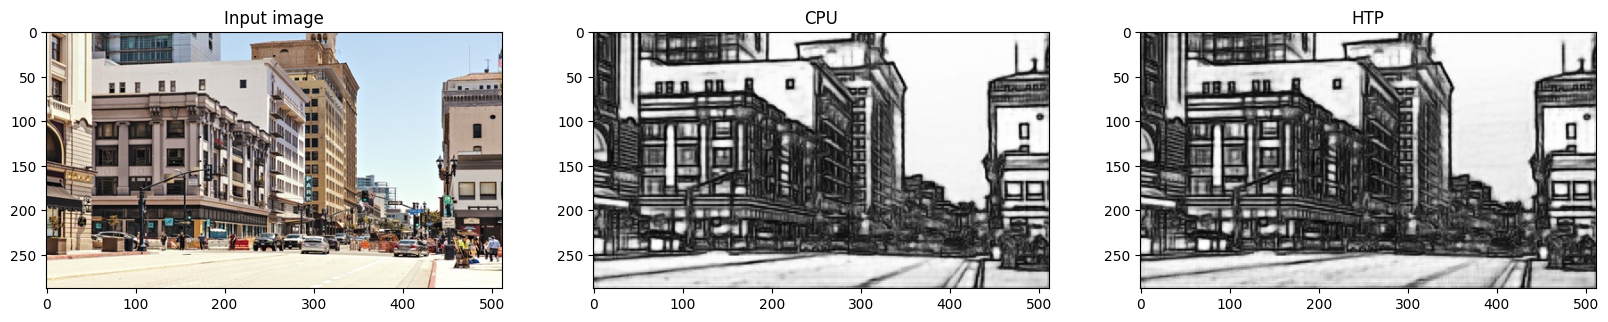

In [32]:
postprocess(["DexiNed/output_cpu/","DexiNed/output_dsp/"])

In [33]:
%%cmd
cd DexiNed
qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log


Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Edge_Detection>cd DexiNed

C:\Qualcomm\AIStack\models\Edge_Detection\DexiNed>qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log
Log File Created: Sat Jun 15 01:34:49 2024
Time Scale: 1e-06
Epoch Timestamp: 1718440489280920 Steady Clock Timestamp: 913496538258
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 25210 us
    Backend (RPC (load binary) time): 12289 us
    Backend (QNN accelerator (load binary) time): 11860 us
    Backend (Accelerator (load binary) time): 11145 us
    Backend (QNN (load binary) time): 25196 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Stats